# Лекція 5 — Оцінка густини та ймовірнісне моделювання


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 9  
**Тема лекції:** Оцінка густини та ймовірнісне моделювання

## Цілі лекції

- [Ймовірність та вірогідність](#prob-vs-likelihood) - p(x\|θ) vs L(θ\|x); MLE 
- [Дискримінативні та генеративні моделі](#disc-vs-gen) - P(y\|x) vs P(x, y) 
- [Параметрична оцінка густини](#parametric) - Гаусів розподіл; MLE 
- [Гістограма як непараметричний оцінювач](#histogram) - Ширина кошика; обмеження 
- [Оцінка густини ядра (KDE)](#kde) - Ядро; пропускна здатність h 
- [Модель суміші гаусіан (GMM)](#gmm) - EM-алгоритм; E-крок; M-крок 
- [Підсумок та порівняння](#summary) - Коли що обирати 

## Проблема

Уявіть, що у вас є 500 вимірів зросту студентів університету. Ви хочете відповісти
на запитання: **яка ймовірність, що наступний студент матиме зріст між 170 і 175 см?**
Або: **цей студент із зростом 210 см — аномалія, чи просто рідкісний, але нормальний випадок?**

Щоб відповісти на ці запитання, вам потрібна функція $\hat{p}(x)$ — оцінка
**щільності ймовірності**: чисельне наближення того, як щільно розташовані точки
вашого розподілу в кожній точці простору.

Ця лекція відповідає на запитання: **як побудувати $\hat{p}(x)$ за вибіркою даних,
не знаючи форми розподілу заздалегідь?** Ми рухаємося від простих до складних методів:

- Спочатку — **параметричний підхід**: припустити гаусівський розподіл і підібрати
  параметри. Швидко, але негнучко.
- Потім — **непараметричний підхід (KDE)**: дати даним "говорити самим за себе",
  не нав'язуючи форму. Гнучко, але пам'ятємо всі точки.
- Нарешті — **змішаний підхід (GMM)**: апроксимувати складний розподіл сумою
  простих гаусіан. Компактно і гнучко водночас.


## Налаштування середовища


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import norm, multivariate_normal
from scipy.special import logsumexp
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLORS = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#762A83",
          "#A6DBA0", "#C2A5CF", "#E08214"]


---
<a id='prob-vs-likelihood'></a>
## 1. Ймовірність та вірогідність

Перш ніж навчати будь-яку модель густини, нам потрібно чітко розуміти,
**що ми оптимізуємо і чому**. Для цього важливо розрізняти два поняття,
які виражаються однією і тією самою формулою, але мають принципово різний зміст.

### Ймовірність: фіксуємо модель, варіюємо дані

$p(x \mid \theta)$ відповідає на питання: _"Якщо параметри моделі рівні $\theta$,
наскільки ймовірно побачити спостереження $x$?"_ Тут $\theta$ — відоме і фіксоване,
а $x$ — вільна змінна. Це те, що ми зазвичай розуміємо під словом "ймовірність".

### Вірогідність: фіксуємо дані, варіюємо модель

$L(\theta \mid x)$ відповідає на питання: _"Якщо ми побачили спостереження $x$,
наскільки правдоподібними є параметри $\theta$?"_ Тут $x$ — зафіксоване (вже виміряне),
а $\theta$ — вільна змінна. Це **вірогідність** (likelihood).

**Ключовий факт:** $p(x \mid \theta)$ і $L(\theta \mid x)$ — це та сама математична
функція, але $p$ ми розглядаємо як функцію від $x$, а $L$ — як функцію від $\theta$.

| Поняття | Вільна змінна | Фіксовано | Питання |
|---------|---------------|-----------|---------|
| **Ймовірність** $p(x \mid \theta)$ | $x$ | $\theta$ | Де можуть бути нові дані? |
| **Вірогідність** $L(\theta \mid x)$ | $\theta$ | $x$ | Які параметри найкраще пояснюють дані? |

### Метод максимальної вірогідності (MLE)

**Ідея MLE:** обрати ті параметри $\hat{\theta}$, при яких спостережені дані
є якомога "правдоподібнішими". Якщо спостереження незалежні, загальна вірогідність
є добутком індивідуальних:

$$\hat{\theta} = \arg\max_{\theta} \prod_{i=1}^{n} p(x_i \mid \theta)$$

Добуток малих чисел дуже швидко наближається до нуля і є чисельно нестабільним.
Тому на практиці беруть логарифм (логарифм — монотонна функція, тож максимум
не зміщується) і отримують **логарифм вірогідності**:

$$\hat{\theta} = \arg\max_{\theta} \, \ell(\theta \mid X) = \arg\max_{\theta} \sum_{i=1}^{n} \log p(x_i \mid \theta)$$

Цей принцип ми будемо використовувати протягом всієї лекції: і для одиничного гаусіана, і для навчання GMM.

#### Демонстрація: фіксуємо дані, варіюємо параметри

Згенеруємо 20 спостережень з $\mathcal{N}(2.0,\, 1.5^2)$ і побудуємо три графіки,
що ілюструють різницю між ймовірністю і вірогідністю:

- **Ліворуч:** $p(x \mid \theta_{true})$ — щільність як функція $x$ при фіксованих
  справжніх параметрах. Ось де, за цією моделлю, можуть з'явитися нові точки.
- **По центру:** $\ell(\mu, \sigma \mid X)$ — поверхня логарифма вірогідності над сіткою
  параметрів. Яскравіший колір = краще пояснення тих самих 20 спостережень.
- **Праворуч:** "переріз" поверхні по $\mu$ при фіксованому $\sigma = \hat{\sigma}$.
  Пік точно відповідає $\hat{\mu}_{MLE}$.

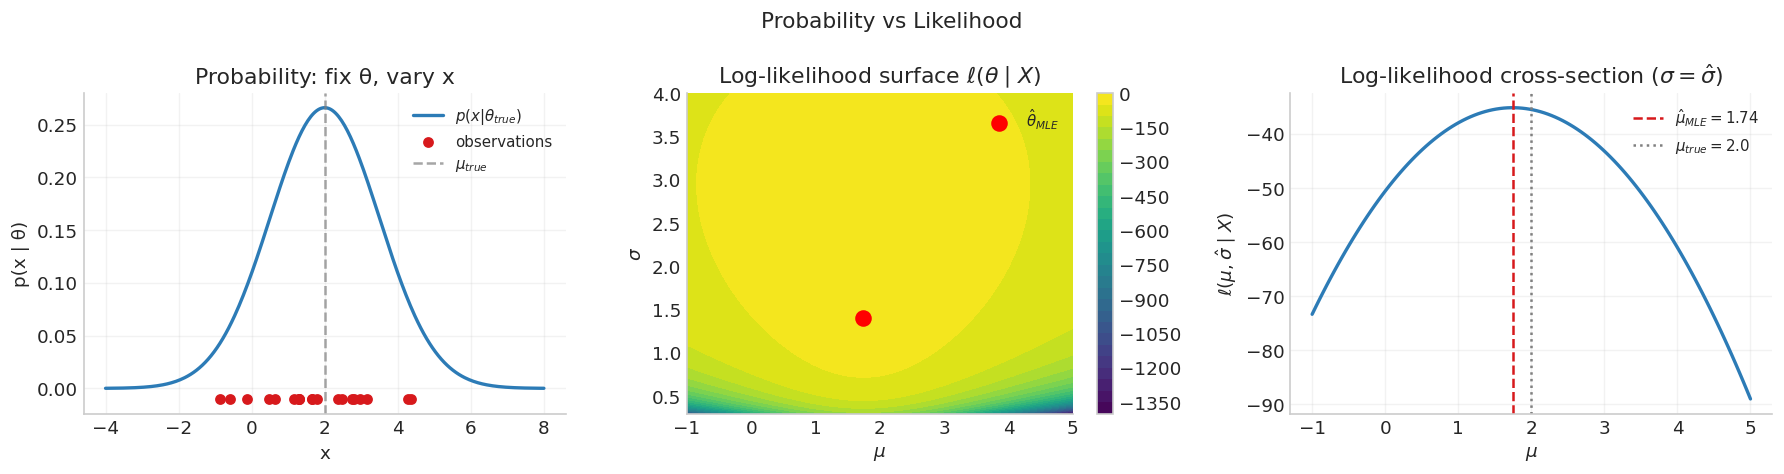

True params:  mu=2.00,  sigma=1.50
MLE estimates: mu=1.74,  sigma=1.40


In [2]:
# True parameters and observed data
mu_true, sigma_true = 2.0, 1.5
rng   = np.random.RandomState(RANDOM_STATE)
X_obs = rng.normal(mu_true, sigma_true, size=20)      # 20 observations

# MLE estimates (closed-form for Gaussian)
mu_hat    = X_obs.mean()
sigma_hat = X_obs.std()

# Grid for (mu, sigma) parameter space
mu_grid    = np.linspace(-1, 5, 120)
sigma_grid = np.linspace(0.3, 4.0, 120)
MU, SIG    = np.meshgrid(mu_grid, sigma_grid)

# Log-likelihood surface: sum_i log N(x_i | mu, sigma)
log_lik = np.array([
    [np.sum(norm.logpdf(X_obs, mu, s)) for mu in mu_grid]
    for s in sigma_grid
])

# Cross-section along mu axis at sigma = sigma_hat
ll_cross = np.array([np.sum(norm.logpdf(X_obs, mu, sigma_hat)) for mu in mu_grid])

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: probability density as a function of x
x_range = np.linspace(-4, 8, 300)
axes[0].plot(x_range, norm.pdf(x_range, mu_true, sigma_true),
             color=COLORS[0], lw=2, label=r"$p(x|\theta_{true})$")
axes[0].scatter(X_obs, np.zeros_like(X_obs) - 0.01,
                color=COLORS[1], s=30, zorder=5, label="observations")
axes[0].axvline(mu_true, color="gray", linestyle="--", alpha=0.7, label=r"$\mu_{true}$")
axes[0].set_xlabel("x"); axes[0].set_ylabel("p(x | θ)")
axes[0].set_title("Probability: fix θ, vary x")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

# Centre: log-likelihood surface
cf = axes[1].contourf(MU, SIG, log_lik, levels=30, cmap="viridis")
axes[1].scatter([mu_hat], [sigma_hat], color="red", s=80, zorder=5,
                label=r"$\hat{\theta}_{MLE}$")
axes[1].set_xlabel(r"$\mu$"); axes[1].set_ylabel(r"$\sigma$")
axes[1].set_title(r"Log-likelihood surface $\ell(\theta \mid X)$")
axes[1].legend(fontsize=9)
plt.colorbar(cf, ax=axes[1])

# Right: cross-section at sigma_hat
axes[2].plot(mu_grid, ll_cross, color=COLORS[0], lw=2)
axes[2].axvline(mu_hat, color=COLORS[1], linestyle="--",
                label=rf"$\hat{{\mu}}_{{MLE}} = {mu_hat:.2f}$")
axes[2].axvline(mu_true, color="gray", linestyle=":",
                label=rf"$\mu_{{true}} = {mu_true}$")
axes[2].set_xlabel(r"$\mu$"); axes[2].set_ylabel(r"$\ell(\mu, \hat{\sigma} \mid X)$")
axes[2].set_title(r"Log-likelihood cross-section ($\sigma = \hat{\sigma}$)")
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.25)

plt.suptitle("Probability vs Likelihood", fontsize=13)
plt.tight_layout(); plt.show()

print(f"True params:  mu={mu_true:.2f},  sigma={sigma_true:.2f}")
print(f"MLE estimates: mu={mu_hat:.2f},  sigma={sigma_hat:.2f}")

#### Що ми бачимо

- **Лівий графік** — ймовірність: крива показує, де можуть опинитися нові дані
  при відомих параметрах. Точки під кривою — наші 20 спостережень.
- **Центральний графік** — вірогідність: один і той самий набір із 20 точок
  пояснюється краще (яскравіше) при одних значеннях $(\mu, \sigma)$ і гірше при інших.
  Червона крапка — максимум поверхні, тобто MLE-оцінка $\hat{\theta}$.
- **Правий графік** — переріз: ліворуч і праворуч від $\hat{\mu}$ логарифм вірогідності
  падає, тобто будь-яке відхилення від MLE-оцінки погіршує пояснення даних.
- MLE-оцінка для гаусіана виявляється простою і замкненою: $\hat{\mu} = \bar{x}$
  (вибіркове середнє), $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$.

---
<a id='disc-vs-gen'></a>
## 2. Дискримінативні та генеративні моделі

Цей розділ пов'язує принцип MLE з задачею оцінки густини і пояснює, чому
оцінка $p(x)$ взагалі є корисною.

### Два підходи до навчання

Уявіть задачу класифікації: є два класи — котики і собачки. Ви хочете навчити модель
визначати клас по фотографії $x$.

**Дискримінативний підхід** навчає $P(y \mid x)$ напряму: "ця картинка — котик чи
собачка?" Модель вчиться проводити межу між класами, але нічого не знає про те,
як виглядають типові картинки кожного класу.

**Генеративний підхід** навчає $P(x \mid y)$ і $P(y)$ окремо: спочатку моделює
"як виглядають котики" і "як виглядають собачки", а потім застосовує теорему Байєса:

$$P(y = k \mid x) = \frac{P(x \mid y = k) \cdot P(y = k)}{P(x)}$$

Знаменник $P(x) = \sum_k P(x \mid y=k) P(y=k)$ — це і є **оцінка густини** всіх
даних. Генеративна модель явно відповідає на питання: "наскільки ймовірна
ця точка $x$ взагалі, незалежно від класу?"

| | Дискримінативна | Генеративна |
|---|---|---|
| **Моделює** | $P(y \mid x)$ напряму | $P(x \mid y)$ та $P(y)$ |
| **Класифікація** | $\hat{y} = \arg\max_y P(y \mid x)$ | через теорему Байєса |
| **Приклади** | Логістична регресія, SVM | Наївний Байєс, GMM |
| **Переваги** | Вища точність при великих $n$ | Генерує нові дані; виявляє аномалії |

### Чому нас цікавить $P(x)$?

KDE та GMM, які ми вивчаємо сьогодні, є **моделями густини для $P(x)$**
(без урахування міток класів). Такі моделі корисні для:

- **Виявлення аномалій**: якщо $\hat{p}(x)$ дуже мала, точка $x$ "не схожа" на
  тренувальні дані — ймовірно, це аномалія.
- **Генерації нових зразків**: можна генерувати нові $x \sim \hat{p}(x)$.
- **Стиснення даних**: замість $n$ точок зберігаємо компактний опис розподілу.

#### Демонстрація: різні межі рішень для однієї задачі

Навчимо логістичну регресію (дискримінативна) та гаусівський наївний байєс
(генеративна) на одних і тих самих даних і порівняємо їх межі рішень.
Наївний байєс моделює $P(x \mid y)$ окремо для кожного класу як гаусіан,
а потім застосовує теорему Байєса.

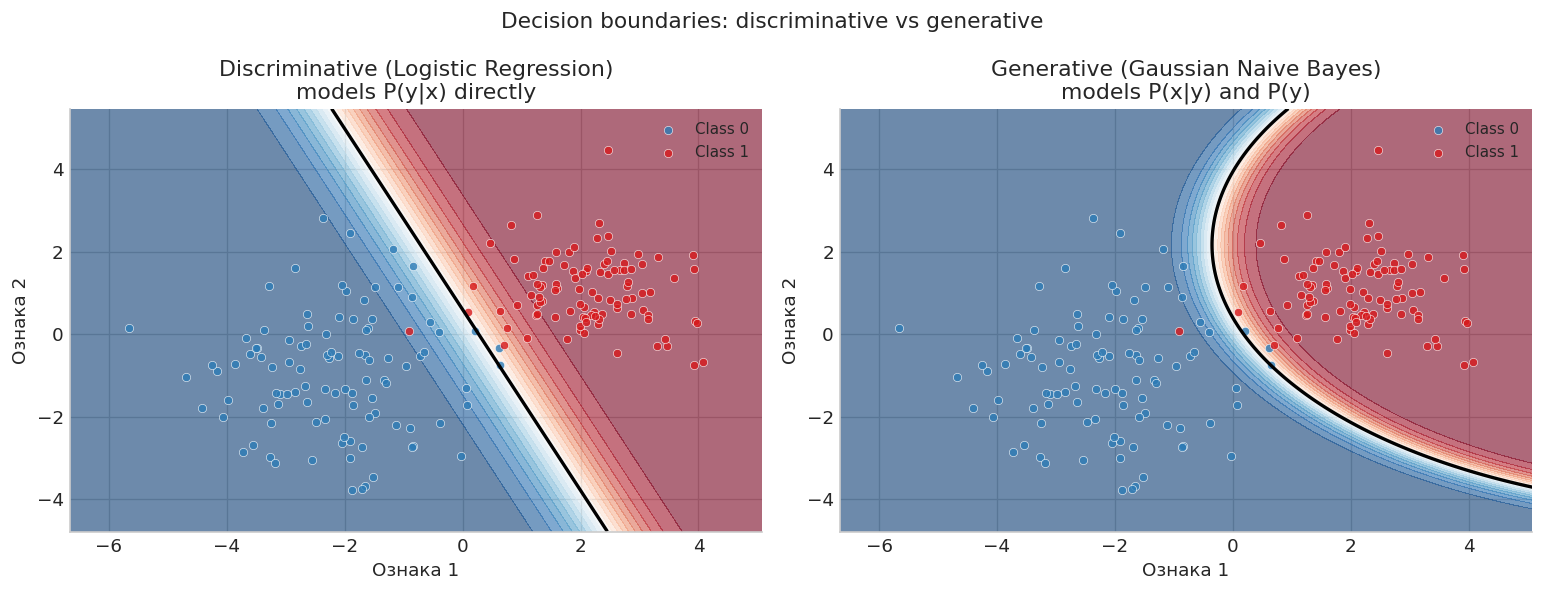

Logistic Regression  accuracy: 0.985
Gaussian Naive Bayes accuracy: 0.985


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay

# Generate an intentionally tricky 2-class dataset
X_cls, y_cls = make_blobs(n_samples=200, centers=[[-2, -1], [2, 1]],
                          cluster_std=[1.4, 0.9], random_state=RANDOM_STATE)

# Fit both models
lr  = LogisticRegression(random_state=RANDOM_STATE).fit(X_cls, y_cls)
gnb = GaussianNB().fit(X_cls, y_cls)

# Grid for contour plots
x_min, x_max = X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1
y_min, y_max = X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid   = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title in zip(
    axes,
    [lr, gnb],
    ["Discriminative (Logistic Regression)\nmodels P(y|x) directly",
     "Generative (Gaussian Naive Bayes)\nmodels P(x|y) and P(y)"]
):
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, proba, levels=[0.5], colors="black", linewidths=2)
    for c, col in zip([0, 1], [COLORS[0], COLORS[1]]):
        mask = y_cls == c
        ax.scatter(X_cls[mask, 0], X_cls[mask, 1],
                   color=col, s=25, alpha=0.8, edgecolors="white", linewidths=0.4,
                   label=f"Class {c}")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Ознака 1"); ax.set_ylabel("Ознака 2")
    ax.set_title(title); ax.legend(fontsize=9)

plt.suptitle("Decision boundaries: discriminative vs generative", fontsize=13)
plt.tight_layout(); plt.show()

lr_acc  = lr.score(X_cls, y_cls)
gnb_acc = gnb.score(X_cls, y_cls)
print(f"Logistic Regression  accuracy: {lr_acc:.3f}")
print(f"Gaussian Naive Bayes accuracy: {gnb_acc:.3f}")

#### Що ми бачимо

- Обидві моделі дають схожі межі рішень, але їхні внутрішні представлення різні.
- **Логістична регресія** вчить лінійну поверхню напряму; вона нічого не знає
  про те, де знаходяться точки кожного класу — лише де проходить межа.
- **Гаусівський наївний байєс** моделює $P(x \mid y=0)$ і $P(x \mid y=1)$
  як два окремі гаусіани. Межа є наслідком застосування теореми Байєса. Якщо нова
  точка потрапляє у зону низької щільності обох класів, байєсівська модель може
  сигналізувати про аномалію — дискримінативна модель на це нездатна.
- Починаючи з наступного розділу ми будемо моделювати $P(x)$ без міток:
  це дасть нам ще більш гнучкі інструменти оцінки густини.

---
<a id='parametric'></a>
## 3. Параметрична оцінка густини

Найпростіший підхід: **припустити форму розподілу** і підібрати параметри
за принципом максимальної вірогідності (MLE).

### Виведення MLE-оцінок для гаусіана

Припустимо, що скалярні спостереження $x_1,\ldots,x_n$ незалежно породжені
розподілом $\mathcal{N}(\mu, \sigma^2)$. Логарифм вірогідності:

$$\ell(\mu, \sigma^2) = \sum_{i=1}^{n} \log \mathcal{N}(x_i;\,\mu,\sigma^2)
= -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log\sigma^2
- \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

**Оцінка $\hat{\mu}$** — прирівнюємо часткову похідну по $\mu$ до нуля:

$$\frac{\partial \ell}{\partial \mu}
= \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i - \mu) = 0
\quad\Longrightarrow\quad
\sum_{i=1}^{n} x_i = n\mu
\quad\Longrightarrow\quad
\boxed{\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_i}$$

Тобто MLE-оцінка середнього — це просте **вибіркове середнє**.

**Оцінка $\hat{\sigma}^2$** — прирівнюємо часткову похідну по $\sigma^2$ до нуля:

$$\frac{\partial \ell}{\partial \sigma^2}
= -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4}\sum_{i=1}^{n}(x_i-\mu)^2 = 0
\quad\Longrightarrow\quad
\boxed{\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{\mu})^2}$$

Тобто MLE-оцінка дисперсії — **вибіркова дисперсія** (з дільником $n$, не $n-1$).

**Узагальнення на $d$ вимірів.** Для $x_i \in \mathbb{R}^d$ і
$\mathcal{N}(\mu, \Sigma)$ логарифм вірогідності набуває вигляду:

$$\ell(\mu,\Sigma) = -\frac{n}{2}\log|\Sigma|
- \frac{1}{2}\sum_{i=1}^{n}(x_i-\mu)^T\Sigma^{-1}(x_i-\mu) + \text{const}$$

Взявши градієнт по $\mu$ і по $\Sigma^{-1}$ та прирівнявши до нуля, отримаємо
ті самі за структурою формули:

$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_i, \qquad
\hat{\Sigma} = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{\mu})(x_i-\hat{\mu})^T$$

### Обмеження параметричного підходу

Формули вище дають правильну відповідь лише якщо **наше припущення про форму
розподілу є вірним**. Якщо реальний розподіл двомодальний або має складну форму,
жодна кількість даних не допоможе: гаусіан "стягнеться" до неправильного центру
і дасть систематично хибну оцінку. Цю ситуацію називають
**неправильною специфікацією моделі** (model misspecification).

#### Демонстрація: гаусівська MLE на трьох різних розподілах

Порівняємо якість MLE-оцінки на трьох датасетах: гаусівському (де метод
правильно специфікований), двомодальному та рівномірному (де ні). На кожному
графіку гістограма — справжній розподіл, крива — гаусіан.

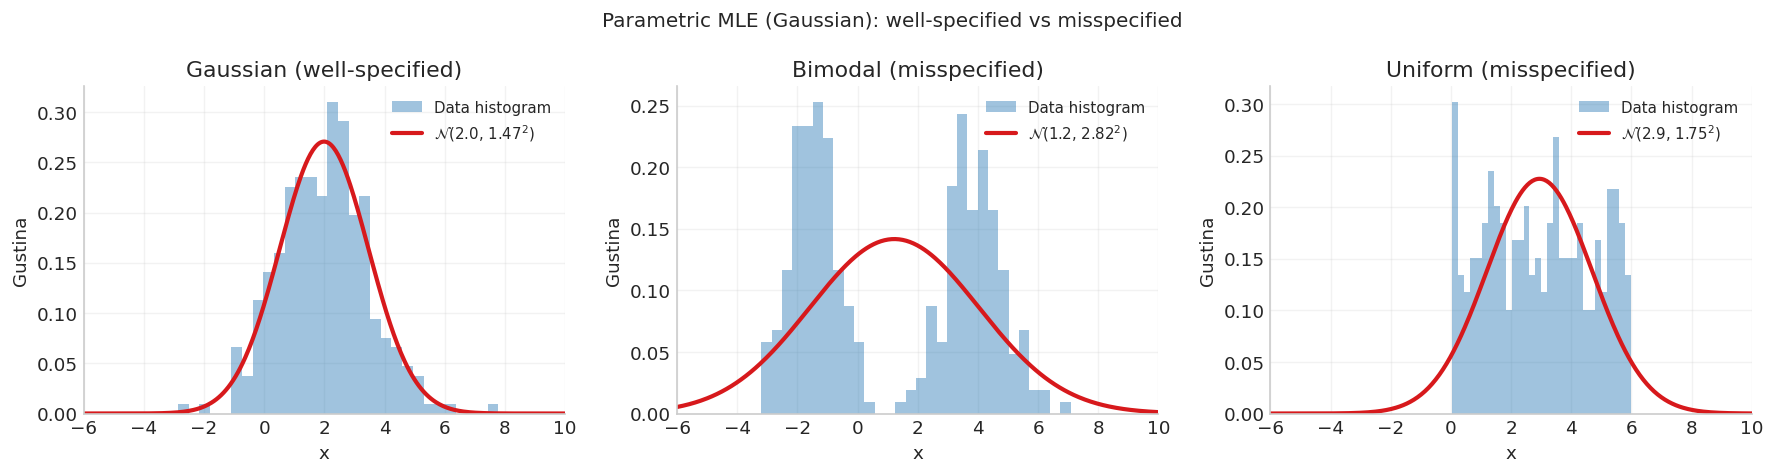

In [4]:
# ── Generate three 1D datasets ────────────────────────────────────────────────
rng      = np.random.RandomState(RANDOM_STATE)
n_pts    = 300
x_range  = np.linspace(-6, 10, 400)

datasets = {
    "Gaussian (well-specified)":  rng.normal(2.0, 1.5, n_pts),
    "Bimodal (misspecified)":     np.concatenate([rng.normal(-1.5, 0.8, n_pts//2),
                                                  rng.normal(4.0,  1.0, n_pts//2)]),
    "Uniform (misspecified)":     rng.uniform(0, 6, n_pts),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, X_d) in zip(axes, datasets.items()):
    # MLE estimates
    mu_mle  = X_d.mean()
    sig_mle = X_d.std()

    # Fitted Gaussian density
    fitted  = norm.pdf(x_range, mu_mle, sig_mle)

    ax.hist(X_d, bins=30, density=True, alpha=0.45,
            color=COLORS[0], label="Data histogram")
    ax.plot(x_range, fitted, color=COLORS[1], lw=2.5,
            label=rf"$\mathcal{{N}}$({mu_mle:.1f}, {sig_mle:.2f}$^2$)")
    ax.set_xlabel("x"); ax.set_ylabel("Gustina")
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.25)
    ax.set_xlim(-6, 10)

plt.suptitle("Parametric MLE (Gaussian): well-specified vs misspecified",
             fontsize=12)
plt.tight_layout(); plt.show()

#### Що ми бачимо

- На **гаусівських даних** MLE майже ідеально відновлює справжній розподіл.
  При правильній специфікації моделі більше даних = кращий результат.
- На **двомодальних даних** один гаусіан не може відтворити два піки:
  він "стягується" між ними, описуючи область, де майже немає реальних точок.
  Збільшення $n$ лише зробить цю хибну оцінку точнішою — але вона залишиться хибною.
- На **рівномірних даних** форма принципово неправильна: гаусіан переоцінює
  центр і недооцінює краї.
- **Висновок:** у реальних задачах ми не знаємо форму розподілу заздалегідь.
  Потрібні методи, які не роблять таких припущень, — **непараметричні оцінювачі**.

---
<a id='histogram'></a>
## 4. Гістограма як непараметричний оцінювач

Перший крок до непараметричної оцінки — гістограма. Ідея проста: розбиваємо
числову вісь на $m$ рівних кошиків шириною $h$ і рахуємо, яка частка точок
потрапила в кожен:

$$\hat{p}(x) = \frac{\text{кількість точок у кошику, що містить } x}{n \cdot h}$$

Ділення на $h$ забезпечує нормування: загальна площа під гістограмою дорівнює 1,
тож це дійсна оцінка густини, а не просто підрахунок частот.

### Bias-variance trade-off для ширини кошика

Ширина $h$ — єдиний гіперпараметр гістограми, і від нього залежить все:

- **Мала $h$** (вузькі кошики): у кожен потрапляє мало точок, оцінка дуже
  нерівна і реагує на випадковий шум. Висока **дисперсія** оцінювача.
- **Велика $h$** (широкі кошики): усереднення занадто великих ділянок,
  дрібна структура розподілу губиться. Великий **зсув** оцінювача.
- **Оптимальна $h$**: балансує між зсувом і дисперсією.

Крім того, гістограма має фундаментальне обмеження: вона **розривна** — значення
щільності стрибкоподібно змінюється на кожній межі кошика. Це артефакт методу,
а не властивість даних. У наступному розділі ми виправимо цей недолік.

#### Демонстрація: ефект ширини кошика

Побудуємо гістограму для двомодальних даних при чотирьох значеннях $h$.
Зверніть увагу: навіть при "найкращому" $h$ крива залишається ступінчастою.

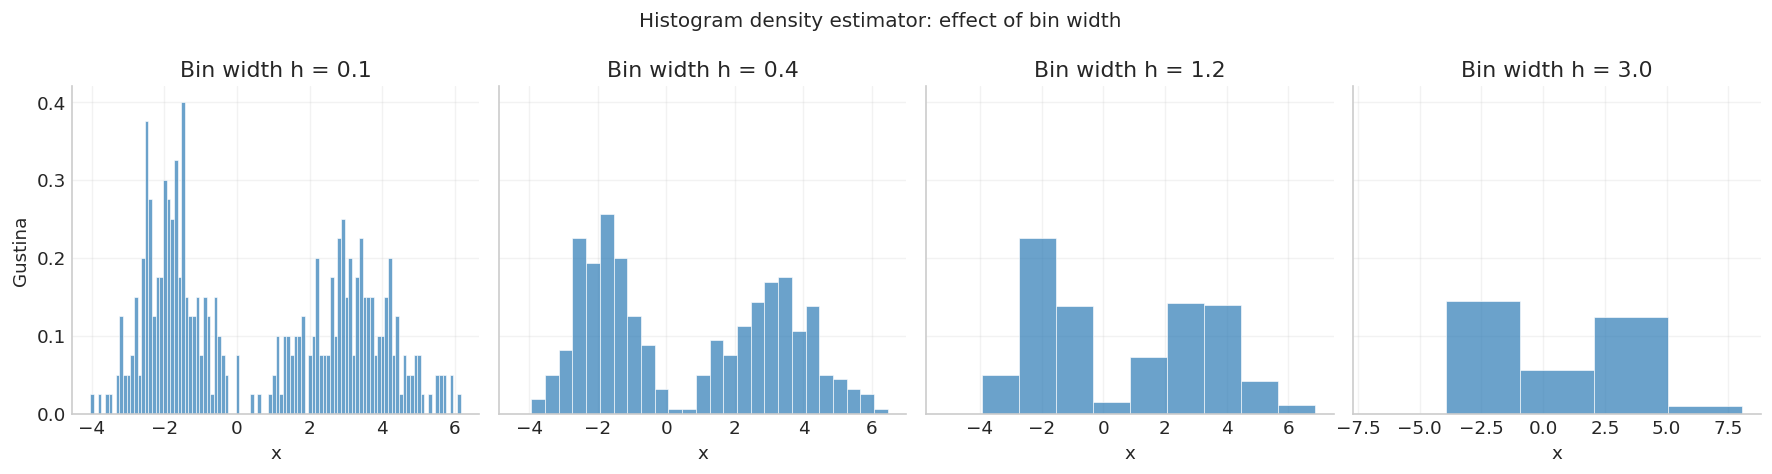

In [5]:
# Bimodal dataset
X_bim = np.concatenate([rng.normal(-2, 0.8, 200), rng.normal(3, 1.2, 200)])

bin_widths = [0.1, 0.4, 1.2, 3.0]
fig, axes  = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, bw in zip(axes, bin_widths):
    bins = np.arange(X_bim.min() - bw, X_bim.max() + bw, bw)
    ax.hist(X_bim, bins=bins, density=True,
            color=COLORS[0], alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("x"); ax.set_title(f"Bin width h = {bw}")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Gustina")
plt.suptitle("Histogram density estimator: effect of bin width", fontsize=12)
plt.tight_layout(); plt.show()

#### Що ми бачимо

- При $h = 0.1$ гістограма надзвичайно нерівна: численні порожні кошики
  чергуються з окремими "голками", і загальна форма розподілу майже нерозрізнена.
- При $h = 0.4$ обидва піки вже помітні, але між ними залишається груба
  ступінчаста структура — форма ще нестабільна через малі кошики.
- При $h = 1.2$ два горби все ще розрізнені, але кожен із них описується лише
  кількома широкими стовпцями; деталі всередині кожного піку загублені.
- При $h = 3.0$ кошики стають настільки широкими, що охоплюють майже всю вісь
  $x$ — залишається два-три прямокутники, які не несуть жодної інформації про
  форму розподілу.
- Ключова проблема гістограми: навіть при найкращому $h$ вона залишається
  **негладкою** (розривною на межах кошиків). Це мотивує перехід до **ядерних оцінювачів**.

---
<a id='kde'></a>
## 5. Оцінка густини ядра (KDE)

### Ідея: "розмазати" кожну точку

Гістограма запитує: "скільки точок потрапило в цей кошик?" KDE запитує щось
тонше: "наскільки близько до точки $x$ знаходяться всі тренувальні точки?"

Формально: кожна тренувальна точка $x_i$ "випромінює" невелику функцію ядра $K$
навколо себе. Щільність у точці $x$ — це сума внесків від усіх тренувальних
точок:

$$\hat{p}(x) = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{h^d} K\!\left(\frac{x - x_i}{h}\right)$$

де:
- $K$ — **ядро** (kernel): симетрична невід'ємна функція з $\int K(u)\,du = 1$.
  Найпоширеніший вибір — гаусівське ядро.
- $h > 0$ — **пропускна здатність** (bandwidth): "ширина" ядра, аналог ширини
  кошика в гістограмі.
- $d$ — вимірність простору; множник $h^d$ нормує ядро.

Оскільки $K$ інтегрується до 1 і кожен доданок ненегативний, $\hat{p}(x)$
автоматично є нормованою щільністю: $\int \hat{p}(x)\,dx = 1$.

### Гаусівське ядро

Найбільш поширений вибір — стандартний гаусіан:

$$K(u) = \frac{1}{\sqrt{2\pi}} \exp\!\left(-\frac{u^2}{2}\right)$$

Результат: кожна тренувальна точка $x_i$ "додає" гаусіан $\mathcal{N}(x_i, h^2)$
до сукупної оцінки. Отже, KDE з гаусівським ядром — це **рівномірно зважена
суміш $n$ гаусіанів**, по одній на кожну тренувальну точку.

**Для багатовимірних даних** ядро застосовується незалежно по кожній координаті
(добуток одновимірних ядер):

$$\hat{p}(x) = \frac{1}{n} \sum_{i=1}^{n} \prod_{k=1}^{d} \frac{1}{h} K\!\left(\frac{x_k - x_{ik}}{h}\right)$$

### Що означає $\mathcal{N}(x_i, h^2)$ в контексті KDE?

Тут гаусіан — це **не модель даних**, а інструмент згладжування. Він описує,
який вплив має тренувальна точка $x_i$ на навколишні значення $x$:

$$K_h(x - x_i)= \frac{1}{h} K\!\left(\frac{x - x_{i}}{h}\right) = \frac{1}{h\sqrt{2\pi}} \exp\!\left(-\frac{(x - x_i)^2}{2h^2}\right)$$

Читайте це так: точка $x_i$ "випромінює" горб шириною $h$, центрований у своєму
ж положенні. Параметри тут не оцінюються: $x_i$ і $h$ обидва фіксовані.
Повна оцінка KDE — це **середнє $n$ таких горбів**, по одному на кожну точку.

### Правило Сільвермана

Як обрати $h$? Для гаусівських даних в одному вимірі оптимальним (в сенсі
середньоквадратичної похибки інтеграції) є:

$$h^* = 1.06 \cdot \hat{\sigma} \cdot n^{-1/5}$$

де $\hat{\sigma}$ — вибіркове стандартне відхилення. Зверніть увагу на $n^{-1/5}$:
це означає, що зі збільшенням кількості даних оптимальна ширина **звужується**
— більше даних дозволяє розрізняти дрібніші деталі розподілу. Для негаусівських
або мультимодальних розподілів правило Сільвермана дає надмірне згладжування, але
слугує хорошою відправною точкою.

> **Загальний принцип:** якщо правило Сільвермана не дає достатньої якості,
> $h$ підбирають крос-валідацією.

#### Демонстрація: KDE і внески окремих ядер

Механіку KDE найкраще видно на **малій** вибірці. Тому ліворуч використовуємо
лише 30 точок: кожна дає внесок у вигляді гаусіана $\frac{1}{n} K_h(x - x_i)$ (сірі
криві), а їх сума дає червону криву. Праворуч — порівняння з повним
датасетом ($n = 400$): KDE проти гістограми.

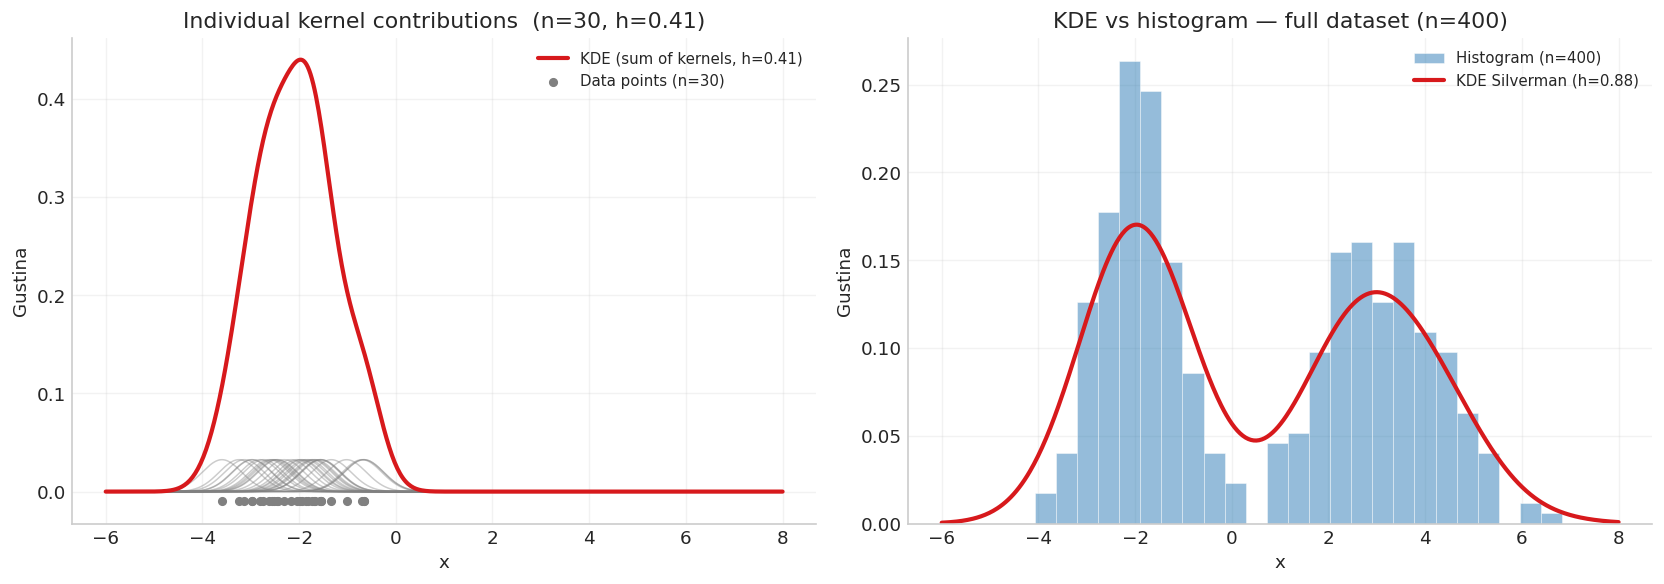

Silverman bandwidth (n=400): h = 0.8754
Silverman bandwidth (n=30):  h = 0.4090


In [6]:
X_bim  = np.concatenate([rng.normal(-2, 0.8, 200), rng.normal(3, 1.2, 200)])
x_plot = np.linspace(-6, 8, 500)

# Silverman bandwidth for the full dataset
h_silverman = 1.06 * X_bim.std() * len(X_bim) ** (-0.2)

# KDE on the full dataset (for the right panel)
kde_sk   = KernelDensity(bandwidth=h_silverman, kernel="gaussian").fit(X_bim[:, None])
density  = np.exp(kde_sk.score_samples(x_plot[:, None]))

# Small subset for the kernel illustration (left panel)
# With n=400 each kernel contributes only 1/400 of its height —
# the gray curves would be invisible. n=30 keeps them legible.
n_demo   = 30
X_demo   = X_bim[:n_demo]
h_demo   = 1.06 * X_demo.std() * n_demo ** (-0.2)

kde_demo    = KernelDensity(bandwidth=h_demo, kernel="gaussian").fit(X_demo[:, None])
density_demo = np.exp(kde_demo.score_samples(x_plot[:, None]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual kernel contributions are visible because n is small
for xi in X_demo:
    k_contrib = norm.pdf(x_plot, xi, h_demo) / n_demo
    axes[0].plot(x_plot, k_contrib, color="gray", alpha=0.4, lw=0.9)
axes[0].plot(x_plot, density_demo, color=COLORS[1], lw=2.5,
             label=f"KDE (sum of kernels, h={h_demo:.2f})")
axes[0].scatter(X_demo, np.full(n_demo, -0.01), color="gray",
                s=20, zorder=5, label=f"Data points (n={n_demo})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("Gustina")
axes[0].set_title(f"Individual kernel contributions  (n={n_demo}, h={h_demo:.2f})")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

# Right: full dataset — KDE vs histogram
axes[1].hist(X_bim, bins=25, density=True, alpha=0.5,
             color=COLORS[0], edgecolor="white", lw=0.5, label="Histogram (n=400)")
axes[1].plot(x_plot, density, color=COLORS[1], lw=2.5,
             label=f"KDE Silverman (h={h_silverman:.2f})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("Gustina")
axes[1].set_title("KDE vs histogram — full dataset (n=400)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.25)

plt.tight_layout(); plt.show()
print(f"Silverman bandwidth (n=400): h = {h_silverman:.4f}")
print(f"Silverman bandwidth (n=30):  h = {h_demo:.4f}")

#### Що ми бачимо

- **Ліворуч** (n=30): кожна сіра крива — внесок однієї точки $\frac{1}{n}K_h(x-x_i)$.
  Їх сума (червона) і є KDE. Видно, як точки в щільних місцях накладають криві
  одна на одну і формують локальний максимум щільності.
- **Праворуч** (n=400): KDE дає значно гладшу і стабільнішу оцінку, ніж
  гістограма з тими самими даними. Обидва піки відтворено без розривів.
- Зверніть увагу: Silverman bandwidth для n=30 більший, ніж для n=400. Це
  відповідає формулі $h^* \propto n^{-1/5}$: менше даних — ширше ядро, бо
  ми менш впевнені в дрібній структурі розподілу.

#### Демонстрація: вплив пропускної здатності $h$

Аналогічно до ширини кошика гістограми, $h$ контролює баланс між зсувом
і дисперсією оцінки KDE. Покажемо чотири значення: занадто мале, помірне,
Сільверман і занадто велике.

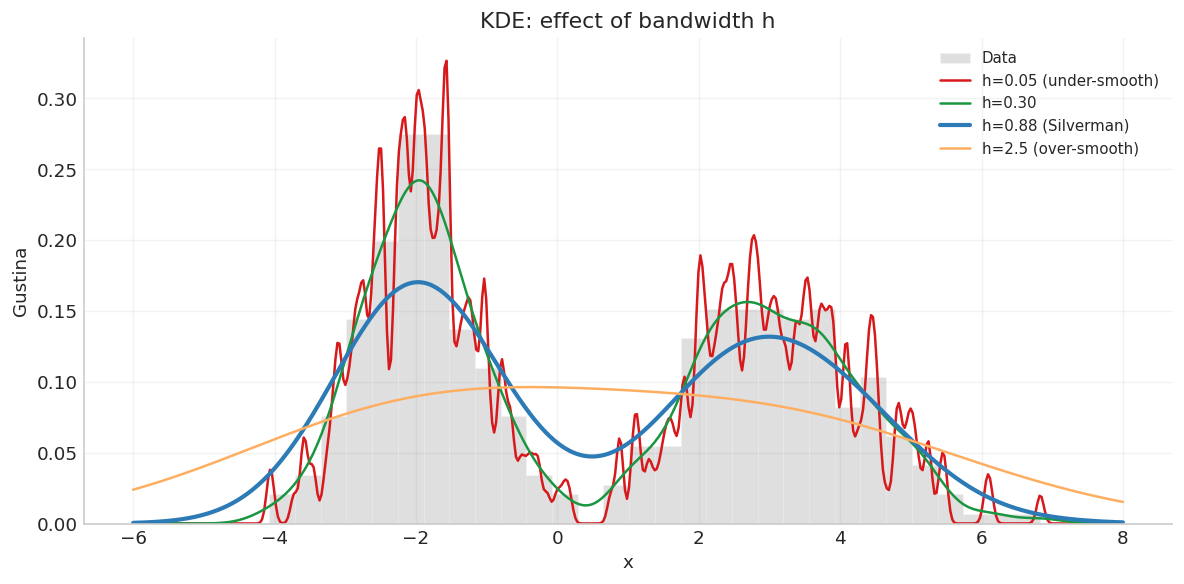

In [7]:
bandwidths = [0.05, 0.3, h_silverman, 2.5]
labels     = ["h=0.05 (under-smooth)", f"h=0.30", f"h={h_silverman:.2f} (Silverman)", "h=2.5 (over-smooth)"]
colors_bw  = [COLORS[1], COLORS[2], COLORS[0], COLORS[3]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(X_bim, bins=30, density=True, alpha=0.25,
        color="gray", edgecolor="white", lw=0.4, label="Data")

for h, label, col in zip(bandwidths, labels, colors_bw):
    kde_h = KernelDensity(bandwidth=h, kernel="gaussian")
    kde_h.fit(X_bim[:, None])
    ld    = np.exp(kde_h.score_samples(x_plot[:, None]))
    lw    = 2.5 if h == h_silverman else 1.5
    ax.plot(x_plot, ld, lw=lw, color=col, label=label)

ax.set_xlabel("x"); ax.set_ylabel("Gustina")
ax.set_title("KDE: effect of bandwidth h")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

#### Що ми бачимо

- Мала $h$ ($0.05$): кожна точка дає вузьку голку, і їх сума виглядає як
  "щітка" — висока дисперсія, оцінка перенавчена на шум.
- Велика $h$ ($2.5$): ядра такі широкі, що перекривають обидва піки і зливають
  їх в один плаский горб — великий зсув, структура загублена.
- Правило Сільвермана і $h = 0.3$ дають схожий результат: гладкий і водночас
  деталізований. Сільверман злегка більший через рівномірний внесок двох мод.
- Правило: якщо дані мультимодальні, Сільверман може переглажувати. Тоді
  $h$ підбирається крос-валідацією по логарифму вірогідності.

#### Демонстрація: двовимірна KDE

KDE природно розширюється на будь-яке число вимірів. Покажемо KDE для
двовимірного датасету у вигляді теплової карти і ізоліній густини.

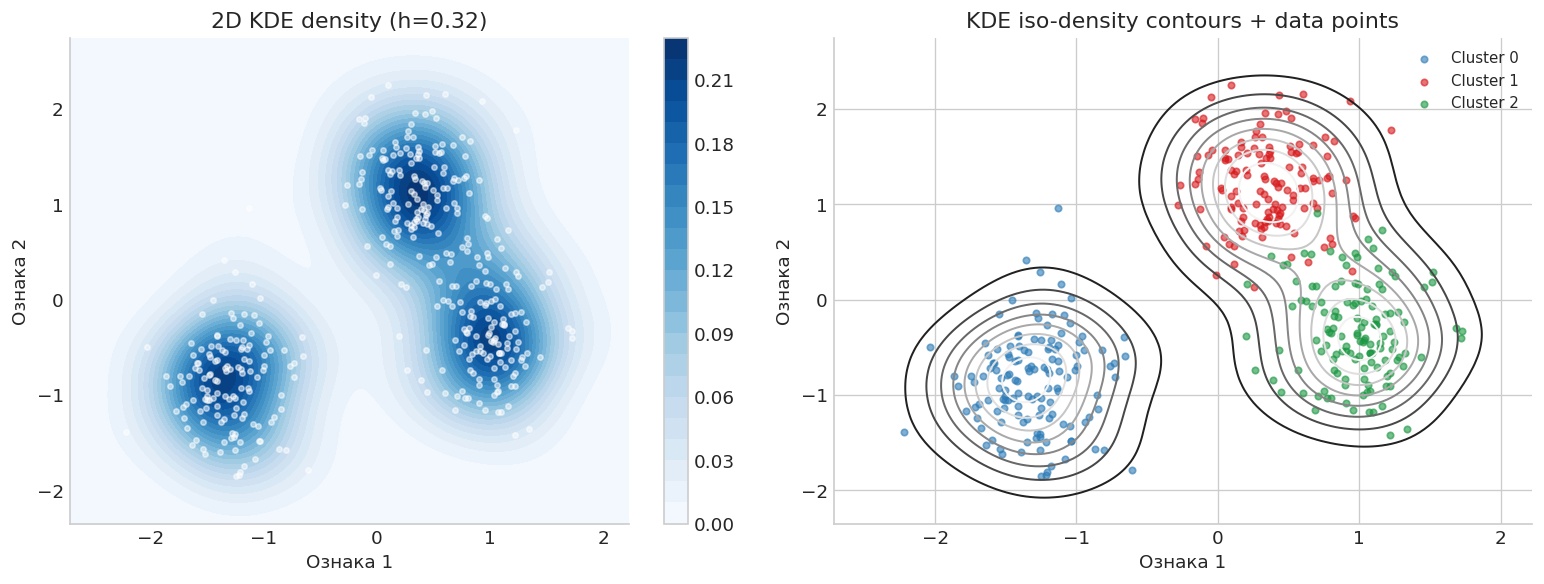

In [8]:
# 2D dataset: three clusters
X_2d, y_2d = make_blobs(n_samples=400, centers=[[-3, -2], [2, 2], [4, -1]],
                         cluster_std=0.9, random_state=RANDOM_STATE)
X_2d = StandardScaler().fit_transform(X_2d)

# Fit KDE with Silverman-like bandwidth
h_2d = 1.06 * X_2d.std() * len(X_2d) ** (-0.2)
kde_2d = KernelDensity(bandwidth=h_2d, kernel="gaussian")
kde_2d.fit(X_2d)

# Evaluation grid
x1g = np.linspace(X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5, 150)
x2g = np.linspace(X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5, 150)
X1G, X2G = np.meshgrid(x1g, x2g)
grid_2d  = np.c_[X1G.ravel(), X2G.ravel()]
Z        = np.exp(kde_2d.score_samples(grid_2d)).reshape(X1G.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: filled contour (density heatmap)
cf = axes[0].contourf(X1G, X2G, Z, levels=25, cmap="Blues")
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], s=10, color="white",
                alpha=0.5, zorder=5)
plt.colorbar(cf, ax=axes[0])
axes[0].set_xlabel("Ознака 1"); axes[0].set_ylabel("Ознака 2")
axes[0].set_title(f"2D KDE density (h={h_2d:.2f})")

# Right: contour lines + scatter
for c, col in zip(range(3), [COLORS[0], COLORS[1], COLORS[2]]):
    mask = y_2d == c
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=15, color=col, alpha=0.6, label=f"Cluster {c}")
axes[1].contour(X1G, X2G, Z, levels=8, cmap="Greys_r", linewidths=1.2)
axes[1].set_xlabel("Ознака 1"); axes[1].set_ylabel("Ознака 2")
axes[1].set_title("KDE iso-density contours + data points")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

#### Що ми бачимо

- KDE у 2D формує неперервну поверхню густини, яка "огинає" хмари точок,
  не знаючи нічого про мітки кластерів.
- Кожна хмара породжує локальний максимум щільності; між хмарами — "сідловини"
  (мінімуми). Ці сідловини можна використовувати як межі для кластеризації або
  виявлення аномалій.
- **Обмеження KDE:** щоб оцінити щільність у точці запиту $x$, потрібно
  обчислити відстані до всіх $n$ тренувальних точок. Складність запиту —
  $O(n \cdot d)$. При великих $n$ або великому $d$ це стає повільним.

---
<a id='gmm'></a>
## 6. Модель суміші гаусіанів (GMM)

### Проблема KDE: пам'ять і "прокляття розмірності"

KDE зберігає **всі** тренувальні точки: модель із 100 000 прикладів у
50 вимірах займає значну пам'ять і потребує обчислення відстані до 100 000
точок при кожному запиті. Чи можна зробити компактніше?

### Ідея GMM: апроксимувати розподіл сумою гаусіан

Якщо KDE — це "рівномірна суміш $n$ гаусіан" (по одній на точку), то GMM
пропонує: а що якщо обмежитись **$K$ гаусіанами**, де $K \ll n$?

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x;\, \mu_k,\, \Sigma_k)$$

де:
- $\pi_k \geq 0$, $\sum_k \pi_k = 1$ — **вагові коефіцієнти** (mixing weights):
  яку частку даних описує $k$-та компонента.
- $\mu_k$ — **центр** $k$-ї компоненти.
- $\Sigma_k$ — **коваріаційна матриця** $k$-ї компоненти: її форма і орієнтація.

Замість зберігання $n$ точок ми зберігаємо лише $K \times (d + d^2 + 1)$ чисел.
При $K = 10$, $d = 50$ це всього близько 25 000 чисел замість $n \times d$.

На відміну від KDE, тут гаусіан — це **параметрична модель компоненти**: вона
описує щільність ймовірності точки $x$ за умови, що її породила компонента $k$:

$$\mathcal{N}(x;\,\mu_k,\Sigma_k) = \frac{1}{(2\pi)^{d/2}|\Sigma_k|^{1/2}}
\exp\!\left(-\frac{1}{2}(x-\mu_k)^T \Sigma_k^{-1}(x-\mu_k)\right)$$

Параметри $\mu_k$ і $\Sigma_k$ **невідомі й оцінюються з даних** алгоритмом EM.
$\Sigma_k$ — повна матриця $d \times d$, тому кожна компонента може моделювати
довільно орієнтовану еліпсоїдну хмару точок.


### Проблема: як навчити GMM?

На перший погляд, просто: максимізуємо логарифм вірогідності за параметрами
$\{\pi_k, \mu_k, \Sigma_k\}$. Але є підводний камінь: логарифм суми не розкладається:

$$\ell = \sum_{i=1}^n \log \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i; \mu_k, \Sigma_k)$$

Взяти похідну і прирівняти до нуля тут **не дає замкненого рішення** через
вкладений логарифм суми. Нам потрібен інший підхід.

### Прихована змінна і задача "курки і яйця"

Введемо **приховану (латентну) змінну** $z_i \in \{1,\ldots,K\}$ — умовне
позначення для того, яка компонента "породила" точку $x_i$. Якби ми знали $z_i$
для кожної точки, задача стала б тривіальною: просто підігнати окрему гаусіану
по всіх точках $i$ із $z_i = k$, і повторити для кожного $k$.

Але ми $z_i$ не знаємо — це і є "прихована" змінна. Ситуація:

> **Якби ми знали $z_i$, ми б оцінили параметри. Якби ми знали параметри, ми б
> оцінили $z_i$. Але ми не знаємо ні того, ні іншого.**

Це класична "задача курки і яйця". Алгоритм EM розв'язує її ітераційно.

### Алгоритм EM (Expectation-Maximisation)

EM починає з **довільних** початкових параметрів і повторює два кроки:

**E-крок (Expectation) — "м'яке" призначення точок до компонент.**

Замість жорсткого призначення $z_i = k$ (яке ми не знаємо), EM обчислює
**відповідальність** $r_{ik}$: наскільки ймовірно, що точку $x_i$ породила
компонента $k$ при поточних параметрах. Це застосування формули Байєса:

$$r_{ik} = p(z_i = k \mid x_i) = \frac{\pi_k \, \mathcal{N}(x_i;\, \mu_k,\, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i;\, \mu_j,\, \Sigma_j)}$$

$r_{ik} \in [0, 1]$ і $\sum_k r_{ik} = 1$ для кожної точки $i$. Точка на
межі між двома кластерами отримає $r_{i1} \approx r_{i2} \approx 0.5$ — "м'яке"
призначення, на відміну від жорсткого k-means.

**M-крок (Maximisation) — переоцінка параметрів.**

Тепер, знаючи $r_{ik}$, знаходимо параметри, що максимізують очікувану
вірогідність. Рішення знову замкнене:

$$N_k = \sum_{i=1}^{n} r_{ik} \quad \text{(ефективна кількість точок у компоненті } k\text{)}$$
$$\pi_k = \frac{N_k}{n}, \qquad \mu_k = \frac{1}{N_k}\sum_{i=1}^{n} r_{ik}\, x_i, \qquad
\Sigma_k = \frac{1}{N_k}\sum_{i=1}^{n} r_{ik}\, (x_i - \mu_k)(x_i - \mu_k)^T$$

Зверніть увагу: формули для $\mu_k$ і $\Sigma_k$ — це просто **зважені середнє
і коваріація**, де ваги — це відповідальності $r_{ik}$.

**Збіжність.** Можна довести, що кожен крок EM **гарантовано не зменшує**
логарифм вірогідності. Тому алгоритм збігається (хоча може і в локальний
максимум). Зупинка — коли покращення $\ell$ менше порогу $\varepsilon$.

#### Демонстрація: процес збіжності EM

Навчимо GMM із $K = 3$ компонентами, починаючи з навмисно неправильних
початкових центрів (зміщені відносно справжніх кластерів). Показуємо
**еліпси коваріацій** при ітераціях 1, 3, 6 та 10.

Кожен еліпс — це межа 95% довіри компоненти. Форма та орієнтація відображають
$\Sigma_k$: витягнутий або повернутий еліпс означає, що компонента охоплює
простягнуту або нахилену хмару точок.

Технічна деталь: ми використовуємо `warm_start=True` і `max_iter=1`, щоб
виконувати рівно по одному кроку EM і знімати "знімки" стану моделі.
`warm_start` означає: при кожному наступному виклику `fit()` не починати
заново, а продовжувати з того, де зупинилися.

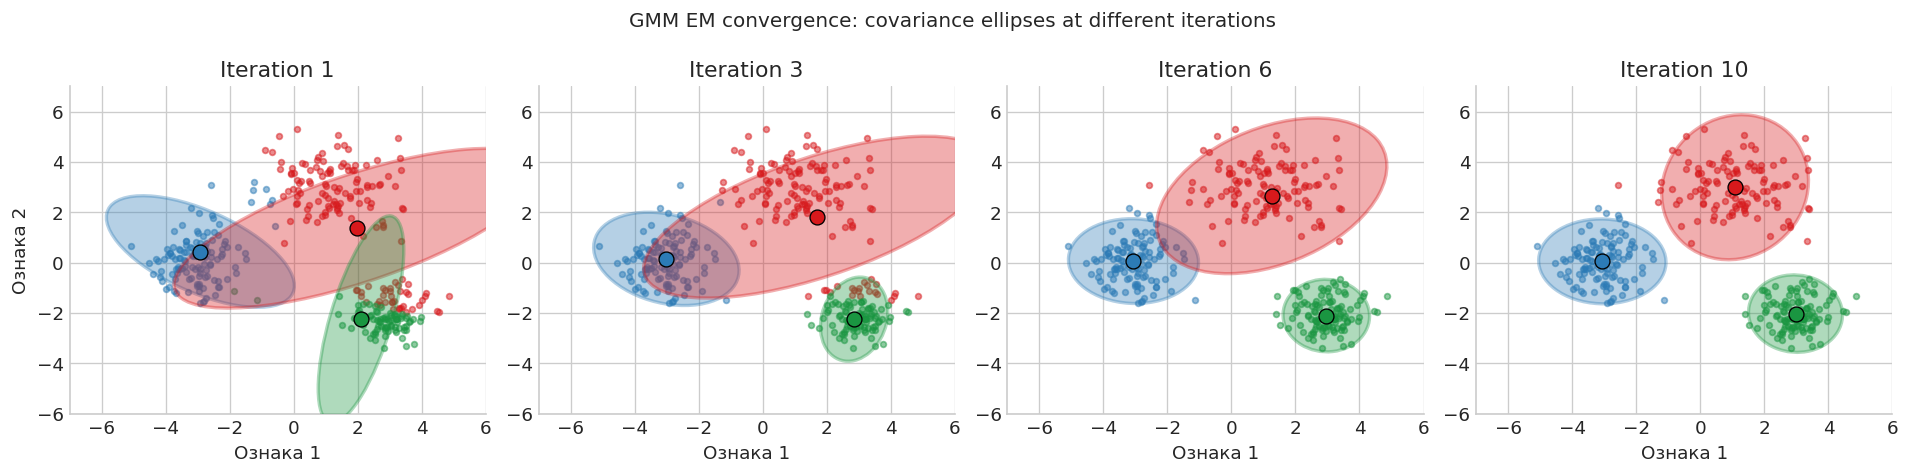

In [9]:
def plot_gmm_ellipses(ax, means, covs, weights, colors, alpha=0.35, lw=2):
    """Draw confidence ellipses for each GMM component."""
    for k, (mu, cov, w, col) in enumerate(zip(means, covs, weights, colors)):
        eigvals, eigvecs = np.linalg.eigh(cov)
        angle  = np.degrees(np.arctan2(*eigvecs[:, 1][::-1]))
        width  = 2 * 2.45 * np.sqrt(eigvals[0])
        height = 2 * 2.45 * np.sqrt(eigvals[1])
        ell    = Ellipse(xy=mu, width=width, height=height, angle=angle,
                         edgecolor=col, facecolor=col, alpha=alpha,
                         linewidth=lw, zorder=4)
        ax.add_patch(ell)
        ax.scatter(*mu, color=col, s=80, zorder=5, edgecolors="black", linewidths=0.8)


# 3-cluster dataset with moderate overlap
X_gmm, _ = make_blobs(
    n_samples=350,
    centers=[[-3, 0], [1, 3], [3, -2]],
    cluster_std=[0.8, 1.1, 0.6],
    random_state=RANDOM_STATE
)

# Deliberately wrong starting means — clearly displaced from true cluster centres
wrong_means = np.array([[-3.0, 3.5], [3.5, 2.5], [0.0, -3.5]])

# warm_start=True: fit() continues from the previous state instead of reinitialising.
# max_iter=1: perform exactly one EM step per fit() call.
# This lets us capture a snapshot at any desired iteration number.
snapshot_its = {1, 3, 6, 10}
snapshots    = {}

gmm_iter = GaussianMixture(
    n_components=3, max_iter=1, n_init=1,
    means_init=wrong_means,
    warm_start=True,
    random_state=RANDOM_STATE,
    covariance_type="full"
)

for it in range(1, 41):
    gmm_iter.fit(X_gmm)
    if it in snapshot_its:
        snapshots[it] = (
            gmm_iter.means_.copy(),
            gmm_iter.covariances_.copy(),
            gmm_iter.weights_.copy(),
            gmm_iter.predict(X_gmm)
        )

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ellipse_colors = [COLORS[0], COLORS[1], COLORS[2]]

for ax, n_it in zip(axes, sorted(snapshot_its)):
    means, covs, weights, labels = snapshots[n_it]
    for c, col in enumerate(ellipse_colors):
        mask = labels == c
        ax.scatter(X_gmm[mask, 0], X_gmm[mask, 1],
                   s=12, color=col, alpha=0.5)
    plot_gmm_ellipses(ax, means, covs, weights, ellipse_colors)
    title = f"Iteration {n_it}" if n_it < 40 else f"Iteration {n_it} (converged)"
    ax.set_xlim(-7, 6); ax.set_ylim(-6, 7)
    ax.set_title(title)
    ax.set_xlabel("Ознака 1")

axes[0].set_ylabel("Ознака 2")
plt.suptitle("GMM EM convergence: covariance ellipses at different iterations",
             fontsize=12)
plt.tight_layout(); plt.show()

#### Що ми бачимо

- На **ітерації 1** центри ще знаходяться у стартових позиціях, далеких від
  реальних кластерів; еліпси великі й не відповідають жодній хмарі точок.
  Відповідальності $r_{ik}$ розподілені майже рівномірно.
- На **ітерації 3** E-крок "помітив", що деякі точки ближчі до реальних хмар,
  ніж до стартових центрів. Центри зміщуються, але форма ще хибна.
- На **ітерації 6** більшість точок вже "знайшли" свій кластер. Еліпси набувають
  правильної форми і орієнтації.
- На **ітерації 10** модель збіглася: еліпси стабільні і добре відповідають
  хмарам точок. EM зробив своє за лічені кроки.

### Крива збіжності

Ліворуч ми побудуємо **lower bound логарифма вірогідності** $\ell(\theta \mid X)$
як функцію номера ітерації EM.

- **Що це за величина?** Це $\sum_{i=1}^n \log p(x_i \mid \theta)$ при поточних
  параметрах $\theta$: наскільки добре модель "пояснює" спостережені дані.
  Чим вище — тим краще.
- **Чому вона монотонна?** Теоретична гарантія EM: кожен E-крок + M-крок
  гарантовано не зменшує $\ell$. Тому крива завжди не спадна.
- **Де зупинятися?** Коли крива "вирівнюється" — подальші ітерації вже нічого
  не дають. Для well-separated кластерів збіжність зазвичай швидка.

### Вибір числа компонент K через BIC та AIC

GMM має гіперпараметр $K$. Як його обрати? Не можна просто максимізувати $\ell$
по $K$: більше компонент завжди дасть вищу вірогідність, але призведе до
перетренування. Потрібен штраф за складність.

Два класичні критерії (менше = краще) - Bayesian Information Criterion (BIC), Akaike Information Criterion (AIC):

$$\text{BIC} = -2\,\ell + p \cdot \ln n$$
$$\text{AIC} = -2\,\ell + 2p$$

де $p$ — кількість вільних параметрів моделі (для GMM з повними коваріаціями:
$p = K \cdot \bigl(d + \frac{d(d+1)}{2} + 1\bigr) - 1$), а $n$ — розмір вибірки.

- Перший член $-2\ell$: "якість підгонки" — менший при кращій моделі.
- Другий член: штраф за складність — зростає з $K$.
- **BIC** штрафує жорсткіше (через $\ln n > 2$ при $n > 8$) і є консервативнішим:
  схильний обирати менші $K$.
- **AIC** штрафує слабше і може схилятися до надмірно складних моделей.
- **Оптимальне $K$** — де критерій досягає мінімуму.

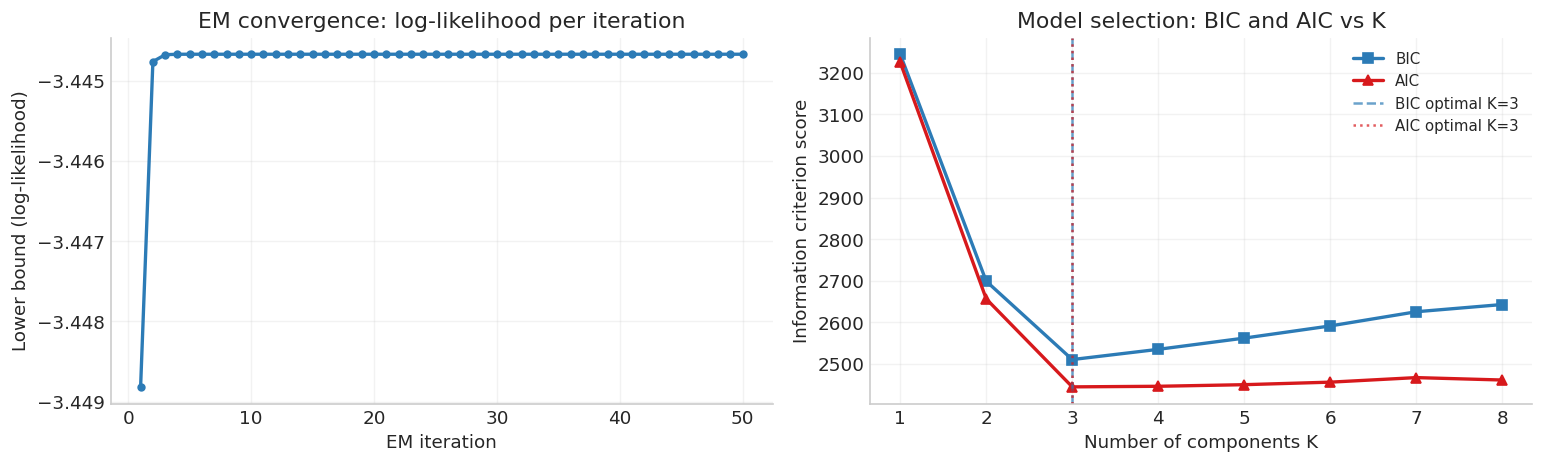

BIC-optimal K: 3    AIC-optimal K: 3


In [10]:
# Log-likelihood curve during training.
# warm_start=True: continue from the previous state at each fit() call.
# max_iter=1: exactly one EM step per call, so we track one point per iteration.
ll_curve  = []
gmm_track = GaussianMixture(n_components=3, max_iter=1, n_init=1,
                              random_state=RANDOM_STATE, warm_start=True)
for it in range(50):
    gmm_track.fit(X_gmm)
    ll_curve.append(gmm_track.lower_bound_)   # lower_bound_ = per-sample log-likelihood

# BIC / AIC for K selection
K_range    = range(1, 9)
bic_scores = []
aic_scores = []

for K in K_range:
    gmm_k = GaussianMixture(n_components=K, max_iter=200, n_init=5,
                             random_state=RANDOM_STATE, covariance_type="full")
    gmm_k.fit(X_gmm)
    bic_scores.append(gmm_k.bic(X_gmm))
    aic_scores.append(gmm_k.aic(X_gmm))

K_best_bic = list(K_range)[np.argmin(bic_scores)]
K_best_aic = list(K_range)[np.argmin(aic_scores)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(ll_curve) + 1), ll_curve,
             color=COLORS[0], lw=2, marker="o", markersize=4)
axes[0].set_xlabel("EM iteration"); axes[0].set_ylabel("Lower bound (log-likelihood)")
axes[0].set_title("EM convergence: log-likelihood per iteration")
axes[0].grid(alpha=0.25)

axes[1].plot(list(K_range), bic_scores, color=COLORS[0], lw=2,
             marker="s", markersize=6, label="BIC")
axes[1].plot(list(K_range), aic_scores, color=COLORS[1], lw=2,
             marker="^", markersize=6, label="AIC")
axes[1].axvline(K_best_bic, color=COLORS[0], linestyle="--", alpha=0.7,
                label=f"BIC optimal K={K_best_bic}")
axes[1].axvline(K_best_aic, color=COLORS[1], linestyle=":", alpha=0.7,
                label=f"AIC optimal K={K_best_aic}")
axes[1].set_xlabel("Number of components K")
axes[1].set_ylabel("Information criterion score")
axes[1].set_title("Model selection: BIC and AIC vs K")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.25)

plt.tight_layout(); plt.show()
print(f"BIC-optimal K: {K_best_bic}    AIC-optimal K: {K_best_aic}")

#### Що ми бачимо

- **Ліворуч:** lower bound різко зростає вже між ітераціями 1 і 2, а після
  ітерації 3 крива практично горизонтальна. EM збігається дуже швидко
  на добре розділених кластерах; більшість з 50 ітерацій є надлишковими.
- **Праворуч:** BIC має чіткий мінімум при $K = 3$, після чого зростає —
  штраф за складність ($p \ln n$) переважає покращення вірогідності.
- AIC також має мінімум при $K = 3$, але після нього залишається майже
  сталим: AIC штрафує слабше і тому менш чутливий до зайвих компонент.
- **BIC є надійнішим критерієм вибору $K$** у даному випадку: він однозначно
  вказує на правильну відповідь, тоді як AIC не дає чіткої відповіді при $K \geq 3$.
- Практичне правило: при невизначеності між BIC і AIC краще обирати BIC —
  він захищає від перефітингу краще, особливо при великих $n$.

---
<a id='summary'></a>
## 7. Підсумок та порівняння

Ми пройшли шлях від найпростіших методів оцінки густини до все більш гнучких.
Зведемо все разом.

### Зведена таблиця методів

| Метод | Параметри | Пам'ять | Гладкість | Генерація | Гіперпараметр |
|---|---|---|---|---|---|
| **Гістограма** | немає | кошики | розривна | ні | ширина кошика $h$ |
| **KDE** | немає | всі $n$ точок | $\infty$-гладка | так | bandwidth $h$ |
| **GMM** | $K \cdot (\mu_k, \Sigma_k, \pi_k)$ | константа | $\infty$-гладка | так | кількість компонент $K$ |

### Практичні рекомендації

- **KDE** — якщо $n$ не надто великий, форма розподілу невідома і потрібна точна
  неперервна оцінка без припущень. Слабке місце: пам'ять і час запиту $O(n \cdot d)$.
- **GMM** — якщо дані мають кластерну структуру або потрібне компактне
  параметричне представлення і генерація нових зразків.
- **Обидва методи** добре підходять для виявлення аномалій: точки з $\hat{p}(x)$
  нижче порога вважаються аномаліями.
- При великому $d$ обидва методи страждають від прокляття розмірності.
  Для таких задач використовують нейромережеві генеративні моделі
  (автоенкодери — тема лекції 11).

#### Демонстрація: пряме порівняння KDE і GMM на складному розподілі

Генеруємо 500 точок із складного чотирикомпонентного розподілу (справжня
щільність нам відома) і порівнюємо, як KDE і GMM із різним $K$ наближають
її. Справжня щільність зображена пунктирною чорною лінією.

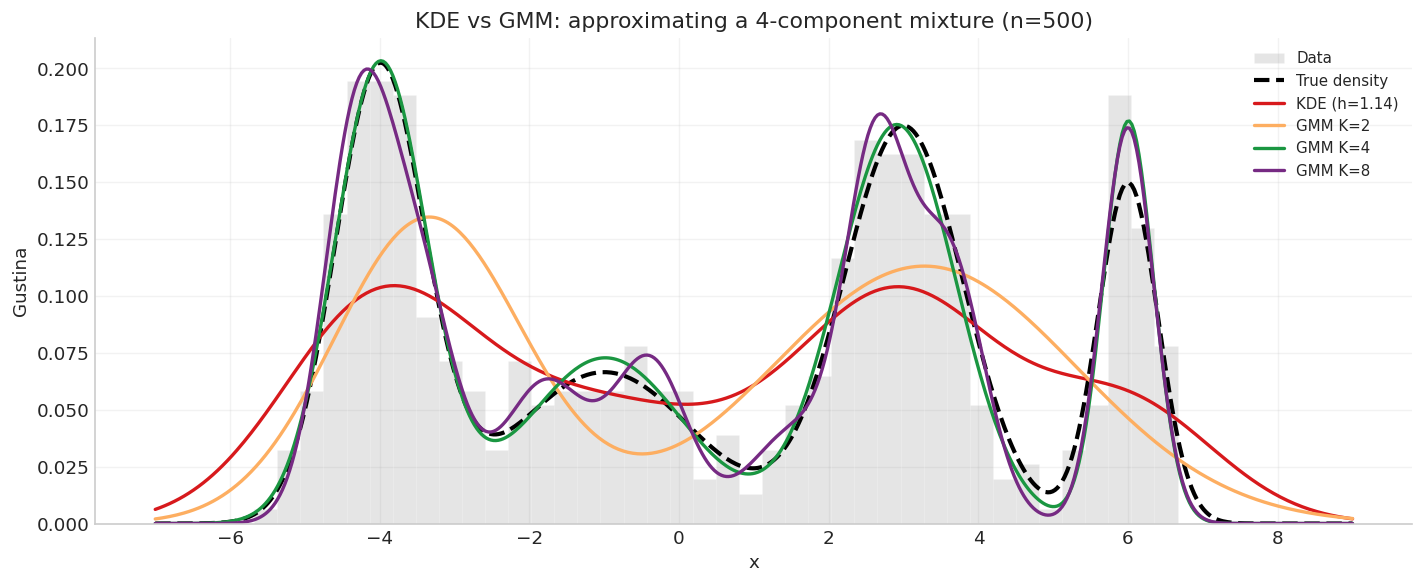

In [11]:
# Complex 1D distribution: mixture of 4 Gaussians
def true_density(x):
    """True mixture density for comparison."""
    return (0.3 * norm.pdf(x, -4, 0.6) +
            0.2 * norm.pdf(x, -1, 1.2) +
            0.35 * norm.pdf(x,  3, 0.8) +
            0.15 * norm.pdf(x,  6, 0.4))

rng2    = np.random.RandomState(7)
# Sample from the mixture manually
component_picks = rng2.choice([0, 1, 2, 3], size=500, p=[0.3, 0.2, 0.35, 0.15])
params = [(-4, 0.6), (-1, 1.2), (3, 0.8), (6, 0.4)]
X_cplx = np.array([rng2.normal(*params[c]) for c in component_picks])

x_eval = np.linspace(-7, 9, 500)
true_d = true_density(x_eval)

# KDE with Silverman bandwidth
h_s    = 1.06 * X_cplx.std() * len(X_cplx) ** (-0.2)
kde_c  = KernelDensity(bandwidth=h_s, kernel="gaussian").fit(X_cplx[:, None])
kde_d  = np.exp(kde_c.score_samples(x_eval[:, None]))

# GMM with K = 2, 4, 8
gmm_colors = {"K=2": COLORS[3], "K=4": COLORS[2], "K=8": COLORS[4]}
gmm_densities = {}
for K in [2, 4, 8]:
    gm = GaussianMixture(n_components=K, n_init=5,
                         random_state=RANDOM_STATE).fit(X_cplx[:, None])
    log_d = gm.score_samples(x_eval[:, None])
    gmm_densities[f"K={K}"] = np.exp(log_d)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(X_cplx, bins=40, density=True, alpha=0.2,
        color="gray", edgecolor="white", lw=0.4, label="Data")
ax.plot(x_eval, true_d, color="black", lw=2.5, linestyle="--", label="True density")
ax.plot(x_eval, kde_d, color=COLORS[1], lw=2, label=f"KDE (h={h_s:.2f})")
for label, dens in gmm_densities.items():
    ax.plot(x_eval, dens, lw=2, color=gmm_colors[label], label=f"GMM {label}")

ax.set_xlabel("x"); ax.set_ylabel("Gustina")
ax.set_title("KDE vs GMM: approximating a 4-component mixture (n=500)")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

#### Що ми бачимо

- **KDE** слідує всім чотирьом пікам, але трохи "розмазує" вузькі компоненти
  (особливо правий пік при $x \approx 6$). Він зберігає всі 500 точок.
- **GMM з $K=4$** знаходить чотири компоненти і добре відтворює справжній
  розподіл, компактно зберігаючи лише 12 параметрів: $(\mu_k, \sigma_k, \pi_k)$
  для кожної з 4 компонент.
- **GMM з $K=2$** — недостатньо компонент: два ліві піки зливаються в один.
- **GMM з $K=8$** — надлишок компонент: зайві компоненти "заповнюють" пустоти
  між справжніми піками, створюючи хибні структури.
- Висновок: при правильному $K$ GMM дає практично таку саму якість, що і KDE,
  але зберігає на 2-3 порядки менше даних.